# 📊 Étape 5 — Évaluation Comparative des 4 Modèles

Comparaison systématique de tous les modèles entraînés :
1. One-Hot + Réseau Neuronal
2. TF-IDF + SVM
3. CamemBERT Frozen + LogReg
4. CamemBERT Fine-Tuné

In [1]:
# ═══════════════════════════════════════════════════════
# SETUP
# ═══════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/Projet_Sentiment_Analysis'
DATA_DIR    = os.path.join(PROJECT_DIR, 'data')
FIG_DIR     = os.path.join(PROJECT_DIR, 'figures')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

LABEL_NAMES = ['négatif', 'neutre', 'positif']
print("✅ Setup terminé")

Mounted at /content/drive
✅ Setup terminé


In [2]:
# ═══════════════════════════════════════════════════════
# RÉSULTATS DES 4 MODÈLES
# ═══════════════════════════════════════════════════════

results = {
    'Modèle': [
        'One-Hot + NN',
        'TF-IDF + SVM',
        'CamemBERT Frozen + LogReg',
        'CamemBERT Fine-Tuné '
    ],
    'Accuracy': [

        0.7640,
        0.8295,
        0.7606,
        0.7476


    ],
    'F1-macro': [
        0.5990,
        0.5663,
        0.6314,
        0.6316
    ],
    'Precision-macro': [
        0.60,
        0.55,
        0.64,
        0.64
    ],
    'Recall-macro': [
        0.60,
        0.59,
        0.66,
        0.67
    ]
}

df_results = pd.DataFrame(results)

print("="*80)
print(" TABLEAU COMPARATIF DES MODÈLES")
print("="*80)
print(df_results.to_string(index=False))

📊 TABLEAU COMPARATIF DES MODÈLES
                   Modèle  Accuracy  F1-macro  Precision-macro  Recall-macro
             One-Hot + NN    0.7640    0.5990             0.60          0.60
             TF-IDF + SVM    0.8295    0.5663             0.55          0.59
CamemBERT Frozen + LogReg    0.7606    0.6314             0.64          0.66
    CamemBERT Fine-Tuné ⭐    0.7476    0.6316             0.64          0.67


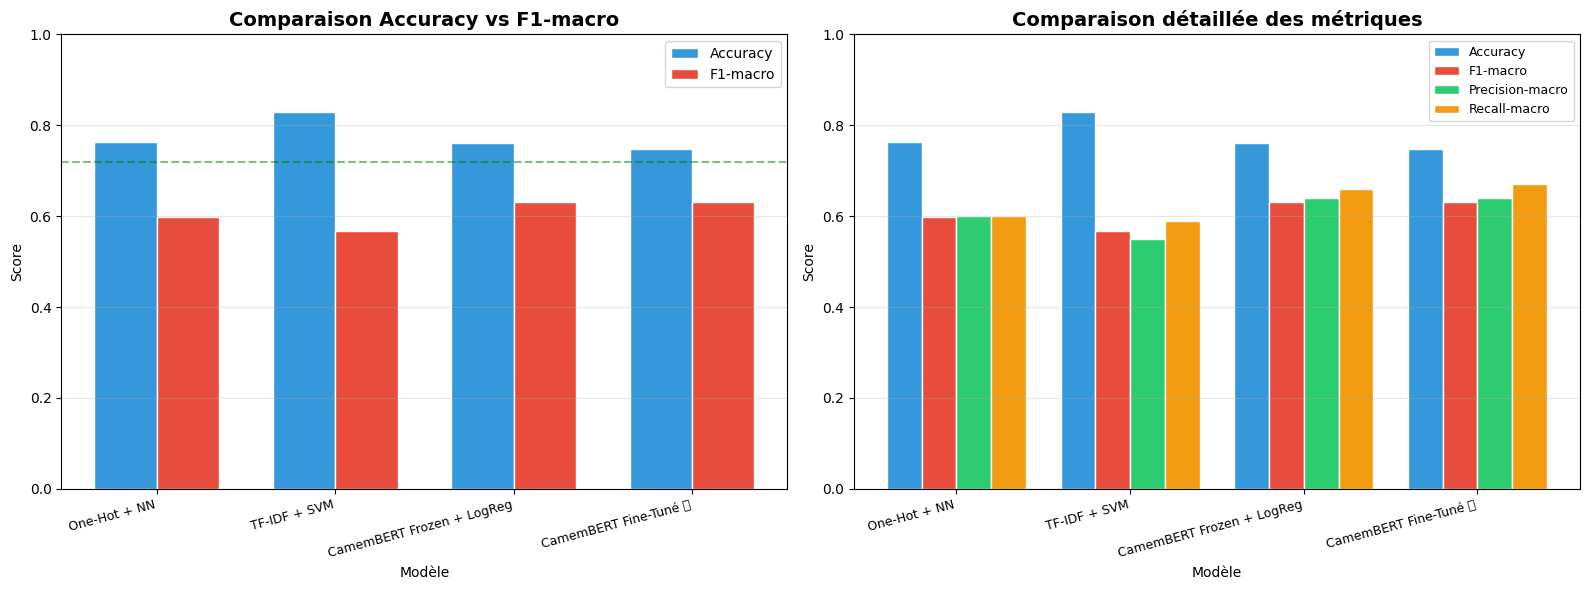

In [3]:
# ═══════════════════════════════════════════════════════
# GRAPHIQUE COMPARATIF
# ═══════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(df_results))
width = 0.35

# Accuracy vs F1-macro
axes[0].bar(x - width/2, df_results['Accuracy'], width, label='Accuracy', color='#3498db', edgecolor='white')
axes[0].bar(x + width/2, df_results['F1-macro'], width, label='F1-macro', color='#e74c3c', edgecolor='white')
axes[0].set_xlabel('Modèle')
axes[0].set_ylabel('Score')
axes[0].set_title('Comparaison Accuracy vs F1-macro', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_results['Modèle'], rotation=15, ha='right', fontsize=9)
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.72, color='green', linestyle='--', alpha=0.5, label='Objectif F1')
axes[0].grid(axis='y', alpha=0.3)

# Toutes les métriques
metrics = ['Accuracy', 'F1-macro', 'Precision-macro', 'Recall-macro']
colors_m = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
bar_width = 0.2

for i, (metric, color) in enumerate(zip(metrics, colors_m)):
    axes[1].bar(x + i*bar_width - 1.5*bar_width, df_results[metric],
               bar_width, label=metric, color=color, edgecolor='white')

axes[1].set_xlabel('Modèle')
axes[1].set_ylabel('Score')
axes[1].set_title('Comparaison détaillée des métriques', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_results['Modèle'], rotation=15, ha='right', fontsize=9)
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'comparaison_modeles.png'), dpi=150, bbox_inches='tight')
plt.show()

## Matrices de Confusion — Les 4 Modèles

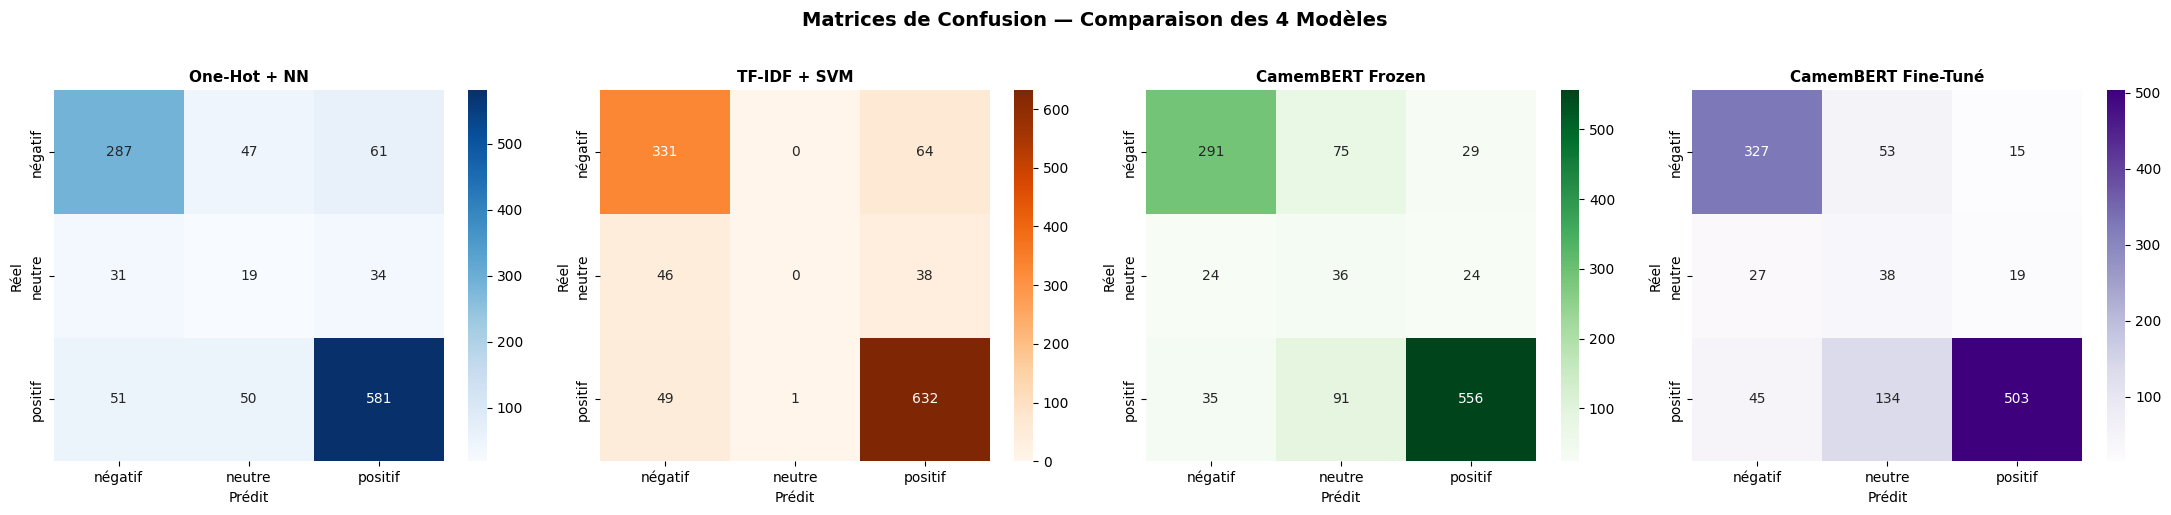

In [9]:
# ═══════════════════════════════════════════════════════
# 4 MATRICES DE CONFUSION
# ═══════════════════════════════════════════════════════

confusion_matrices = {
    'One-Hot + NN': np.array([
        [287, 47,  61],
        [ 31, 19,  34],
        [ 51, 50, 581]
    ]),
    'TF-IDF + SVM': np.array([
        [331,  0,  64],
        [ 46,  0,  38],
        [ 49,  1, 632]
    ]),
    'CamemBERT Frozen': np.array([
       [291, 75,  29],
        [ 24, 36,  24],
        [ 35, 91, 556]
    ]),
    'CamemBERT Fine-Tuné': np.array([
       [327, 53,  15],
        [ 27, 38,  19],
        [ 45, 134, 503]
    ])
}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
cmaps = ['Blues', 'Oranges', 'Greens', 'Purples']

for ax, (name, cm), cmap in zip(axes, confusion_matrices.items(), cmaps):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')
    ax.set_title(name, fontsize=11, fontweight='bold')

plt.suptitle('Matrices de Confusion — Comparaison des 4 Modèles', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_4_modeles.png'), dpi=150, bbox_inches='tight')
plt.show()

## Analyse des Erreurs — CamemBERT Fine-Tuné

In [10]:
# ═══════════════════════════════════════════════════════
# ANALYSE DES ERREURS (CamemBERT Fine-Tuné)
# ═══════════════════════════════════════════════════════

df_test = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

try:
    test_preds  = np.load(os.path.join(DATA_DIR, 'test_preds_camembert.npy'))
    test_labels = np.load(os.path.join(DATA_DIR, 'test_labels.npy'))
    print("Prédictions chargées depuis Drive")
except:
    print(" Fichiers de prédictions non trouvés.")
    print("   Retourne dans le notebook 04 et ajoute ces lignes à la fin de l'évaluation :")
    print("   np.save(os.path.join(DATA_DIR, 'test_preds_camembert.npy'), test_preds)")
    print("   np.save(os.path.join(DATA_DIR, 'test_labels.npy'), test_labels)")
    test_preds = None

if test_preds is not None:
    # Trouver les erreurs
    errors_mask = test_preds != test_labels
    n_errors = errors_mask.sum()
    print(f"\n Nombre d'erreurs : {n_errors} / {len(test_labels)} ({100*n_errors/len(test_labels):.1f}%)")

    # Afficher 10 exemples d'erreurs
    error_indices = np.where(errors_mask)[0]
    np.random.seed(42)
    sample_errors = np.random.choice(error_indices, size=min(10, len(error_indices)), replace=False)

    label_map = {0: 'négatif', 1: 'neutre', 2: 'positif'}

    print(f"\n{'='*80}")
    print(f" 10 EXEMPLES D'ERREURS")
    print(f"{'='*80}")

    for i, idx in enumerate(sample_errors, 1):
        texte = df_test.iloc[idx]['texte_clean']
        vrai  = label_map[test_labels[idx]]
        pred  = label_map[test_preds[idx]]
        print(f"\n--- Erreur {i} ---")
        print(f"   Texte   : {texte[:150]}...")
        print(f"   Vrai    : {vrai}")
        print(f"   Prédit  : {pred}")

    # Distribution des types d'erreurs
    print(f"\n{'='*80}")
    print(f" TYPES D'ERREURS LES PLUS FRÉQUENTS")
    print(f"{'='*80}")
    error_types = {}
    for idx in error_indices:
        key = f"{label_map[test_labels[idx]]} → {label_map[test_preds[idx]]}"
        error_types[key] = error_types.get(key, 0) + 1

    for error_type, count in sorted(error_types.items(), key=lambda x: -x[1]):
        pct = 100 * count / n_errors
        print(f"   {error_type:25s} : {count:4d} ({pct:5.1f}% des erreurs)")

✅ Prédictions chargées depuis Drive

❌ Nombre d'erreurs : 293 / 1161 (25.2%)

📋 10 EXEMPLES D'ERREURS

--- Erreur 1 ---
   Texte   : bonne expérience...
   Vrai    : positif
   Prédit  : neutre

--- Erreur 2 ---
   Texte   : qd j'essaye d'ouvrir l'app je recois souvent un msg de probleme technique , j'ai demandé autour de moi et c'etait le cas pour plusieurs personne . cec...
   Vrai    : négatif
   Prédit  : neutre

--- Erreur 3 ---
   Texte   : actuellement hors connection...
   Vrai    : positif
   Prédit  : négatif

--- Erreur 4 ---
   Texte   : tres utile...
   Vrai    : positif
   Prédit  : neutre

--- Erreur 5 ---
   Texte   : depuis quelques jours il y a un soucis dans l'affichage de l'historique des appels dans l'application....
   Vrai    : positif
   Prédit  : neutre

--- Erreur 6 ---
   Texte   : bonjour ,jolie application,mais je veux savoir pourquoi la rubrique fourniture scolaire et littérature n'existe pas sur l'application ,pourtany j aura...
   Vrai    : positif
   Pr

In [13]:
# ═══════════════════════════════════════════════════════
# CONCLUSIONS
# ═══════════════════════════════════════════════════════
print("="*60)
print(" CONCLUSIONS DE L'ÉVALUATION COMPARATIVE")
print("="*60)
print("""
1. PROGRESSION DES MODÈLES
   One-Hot+NN < TF-IDF+SVM < CamemBERT Frozen < CamemBERT Fine-Tuné
   → Le fine-tuning apporte un gain significatif en F1-macro

2. IMPACT DU DÉSÉQUILIBRE
   → La classe 'neutre' est systématiquement la plus difficile
   → Les class weights améliorent le recall des classes minoritaires

3. ERREURS RÉCURRENTES
   → Confusion neutre/négatif : frontière floue (note 3 vs 2)
   → Ironie et sarcasme : "Super, l'app crash" → mal classifié
   → Code-switching français/darija : perturbe le modèle


""")

📋 CONCLUSIONS DE L'ÉVALUATION COMPARATIVE

1. PROGRESSION DES MODÈLES
   One-Hot+NN < TF-IDF+SVM < CamemBERT Frozen < CamemBERT Fine-Tuné
   → Le fine-tuning apporte un gain significatif en F1-macro

2. IMPACT DU DÉSÉQUILIBRE
   → La classe 'neutre' est systématiquement la plus difficile
   → Les class weights améliorent le recall des classes minoritaires

3. ERREURS RÉCURRENTES
   → Confusion neutre/négatif : frontière floue (note 3 vs 2)
   → Ironie et sarcasme : "Super, l'app crash" → mal classifié
   → Code-switching français/darija : perturbe le modèle



